Importación de librerias

In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
#Carga de datos
df = pd.read_csv(r'C:\Movie_Insights\data\raw\tmdb_2020_to_2025.csv')

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (9999, 15)


,Unnamed: 0,adult,backdrop_path,genre_ids,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count
0,0,False,/hpXBJxLD2SEf8l2CspmSeiHrBKX.jpg,"[18, 27, 14]",1062722,en,Frankenstein,"Dr. Victor Frankenstein, a brilliant but egoti...",951.3460,/g4JtvGlQO7DByTI6frUobqvSL3R.jpg,2025-10-17,Frankenstein,False,7.907,1075
1,1,False,/d6HIjhk2f8BiZnVQ43gUv67khmX.jpg,"[10749, 18]",1231813,ko,자매의 스와핑,Sisters Ji-soo and Ji-yeong decided to sell th...,14.2714,/lqjkmFmV62JEUGKK7E1UwX7PDDT.jpg,2023-12-19,Sister Swapping,False,6.600,14
2,2,False,/82lM4GJ9uuNvNDOEpxFy77uv4Ak.jpg,"[28, 878, 12]",1242898,en,Predator: Badlands,"Cast out from his clan, a young Predator finds...",314.6851,/pHpq9yNUIo6aDoCXEBzjSolywgz.jpg,2025-11-05,Predator: Badlands,False,7.200,266
3,3,False,/6zKjoOOb3OZnZuiHtQZn4Kd69Gq.jpg,"[27, 53]",1197137,en,Black Phone 2,"Four years after escaping The Grabber, Finney ...",242.3412,/xUWUODKPIilQoFUzjHM6wKJkP3Y.jpg,2025-10-15,Black Phone 2,False,7.186,437
4,4,False,/vZK3f5N8Fv2LcyFYLwt6dz0HE1H.jpg,"[28, 35]",1161617,en,Code 3,A burned-out paramedic tries to survive his la...,251.8624,/gIAYMDb5mIAeCAj76q1sRsKjkzo.jpg,2025-09-12,Code 3,False,7.075,87


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9999 non-null   int64  
 1   adult              9999 non-null   bool   
 2   backdrop_path      8118 non-null   str    
 3   genre_ids          9999 non-null   str    
 4   id                 9999 non-null   int64  
 5   original_language  9999 non-null   str    
 6   original_title     9999 non-null   str    
 7   overview           9721 non-null   str    
 8   popularity         9999 non-null   float64
 9   poster_path        9756 non-null   str    
 10  release_date       9999 non-null   str    
 11  title              9999 non-null   str    
 12  video              9999 non-null   bool   
 13  vote_average       9999 non-null   float64
 14  vote_count         9999 non-null   int64  
dtypes: bool(2), float64(2), int64(3), str(8)
memory usage: 1.0 MB


In [25]:
df.describe()

,Unnamed: 0,id,popularity,vote_average,vote_count
count,9999.000000,9.999000e+03,9999.000000,9999.000000,9999.000000
mean,4999.000000,9.797428e+05,5.814750,4.551764,221.900790
std,2886.607005,2.630966e+05,13.101449,2.968713,879.465244
min,0.000000,5.492000e+03,0.192900,0.000000,0.000000
25%,2499.500000,7.845155e+05,3.673650,0.000000,0.000000
50%,4999.000000,9.500850e+05,4.320600,5.708000,6.000000
75%,7498.500000,1.175968e+06,5.650550,6.724000,61.000000
max,9998.000000,1.576287e+06,951.346000,10.000000,21265.000000


In [26]:
df.columns

Index(['Unnamed: 0', 'adult', 'backdrop_path', 'genre_ids', 'id',
       'original_language', 'original_title', 'overview', 'popularity',
       'poster_path', 'release_date', 'title', 'video', 'vote_average',
       'vote_count'],
      dtype='str')

Valores nulos

In [27]:
df.isnull().sum().sort_values(ascending=False)
(df.isnull().sum() / len(df)) * 100

Unnamed: 0            0.000000
adult                 0.000000
backdrop_path        18.811881
genre_ids             0.000000
id                    0.000000
original_language     0.000000
original_title        0.000000
overview              2.780278
popularity            0.000000
poster_path           2.430243
release_date          0.000000
title                 0.000000
video                 0.000000
vote_average          0.000000
vote_count            0.000000
dtype: float64

Limpieza de datos

In [28]:
#eliminar columnas innecesarias
df = df.drop(columns=['Unnamed: 0'])

In [29]:
#convertir tipos de datos
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

In [30]:
#Imputación
df['overview'] = df['overview'].fillna('Sin descripción')
df = df.dropna(subset=['poster_path'])

In [31]:
#transformando genre_ids de str a lista
df['genre_ids'] = df['genre_ids'].apply(ast.literal_eval)

In [32]:
#Normalización de variables categóricas
df = df.drop_duplicates(subset='id')

In [33]:
#eliminación de duplicads
df = df.drop_duplicates(subset='id')

In [34]:
#creación de variables utiles
df['year'] = df['release_date'].dt.year

Análisis Exploratorio -- EDA

In [35]:
#resumen estadistico
df.describe()

,id,popularity,release_date,vote_average,vote_count,year
count,9.756000e+03,9756.000000,9756,9756.000000,9756.000000,9756.000000
mean,9.748755e+05,5.849083,2022-12-11 09:23:05.977859,4.648110,227.422612,2022.418819
min,5.492000e+03,2.119600,2020-01-01 00:00:00,0.000000,0.000000,2020.000000
25%,7.792990e+05,3.679275,2021-08-08 00:00:00,2.000000,1.000000,2021.000000
50%,9.459490e+05,4.330500,2022-10-27 00:00:00,5.800000,7.000000,2022.000000
75%,1.168288e+06,5.667225,2024-05-23 00:00:00,6.759000,65.000000,2024.000000
max,1.576287e+06,951.346000,2025-12-31 00:00:00,10.000000,21265.000000,2025.000000
std,2.616116e+05,13.259742,NaN,2.921043,889.646802,1.655914


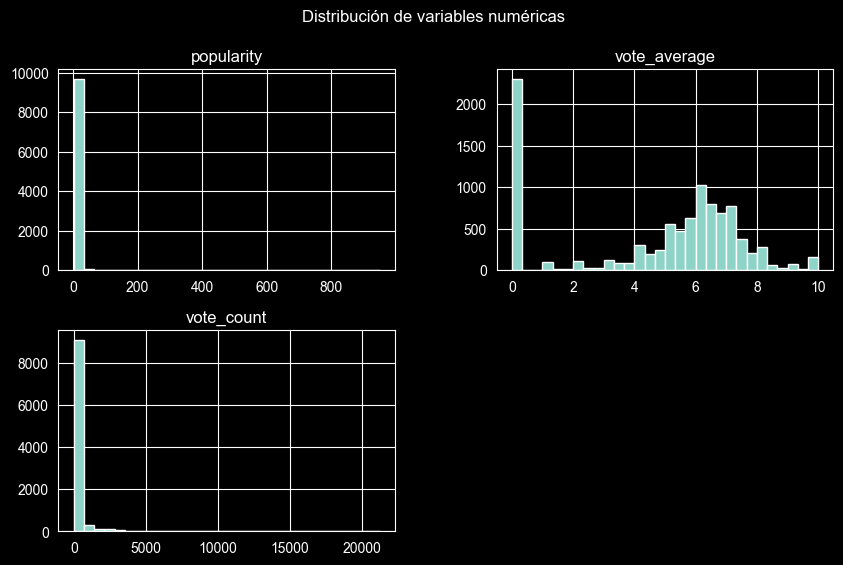

In [36]:
#distribución de variables numericas
num_cols = ['popularity', 'vote_average', 'vote_count']

df[num_cols].hist(bins=30, figsize=(10,6))
plt.suptitle("Distribución de variables numéricas")
plt.show()

In [37]:
#conteo por idioma
df['original_language'].value_counts().head(10)

original_language
en    5403
fr     540
ja     516
es     464
it     270
tl     245
ko     218
de     212
zh     183
hi     172
Name: count, dtype: int64

In [38]:
#pelicula por año
df['original_language'].value_counts().head(10)

original_language
en    5403
fr     540
ja     516
es     464
it     270
tl     245
ko     218
de     212
zh     183
hi     172
Name: count, dtype: int64

In [39]:
#Top 10 peliculas mas populares
df[['title','popularity']].sort_values(by='popularity', ascending=False).head(10)

,title,popularity
0,Frankenstein,951.3460
7,Playdate,388.3856
2,Predator: Badlands,314.6851
4,Code 3,251.8624
3,Black Phone 2,242.3412
6,War of the Worlds,204.4781
5,End of Loyalty,186.6110
8,Abyss,179.5906
10,Chainsaw Man - The Movie: Reze Arc,154.4678
9,Baramulla,148.1601


In [40]:
#top peliculas mwjor calificadas
df[['title','vote_average']].sort_values(by='vote_average', ascending=False).head(10)

,title,vote_average
1675,Resurrection,10.0
7656,Brother,10.0
5574,Raggedy Ann: The Musical Adventure,10.0
5569,Repressed,10.0
7073,Pandemonic,10.0
3419,Six Days to Die,10.0
8914,Drifting Petals,10.0
7290,Memories of the Sítio,10.0
5703,Ascetic,10.0
2731,Evil Puddle,10.0


Matriz de correlación

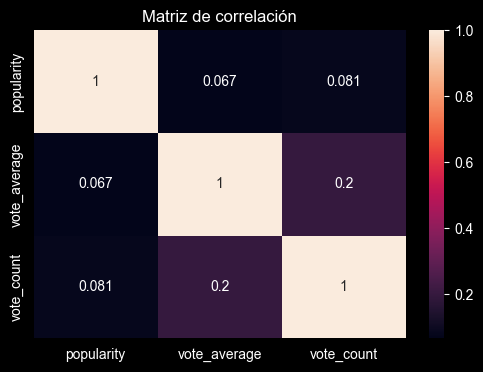

In [41]:
corr = df[['popularity','vote_average','vote_count']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.show()

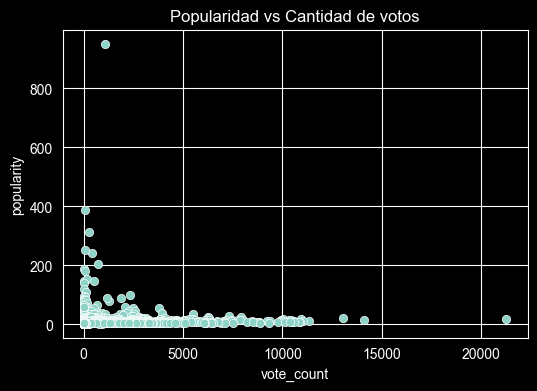

In [42]:
#relación entre popularidad vs votos
plt.figure(figsize=(6,4))
sns.scatterplot(x='vote_count', y='popularity', data=df)
plt.title("Popularidad vs Cantidad de votos")
plt.show()

In [43]:
df.to_csv('data/processed/tmdb_movies_clean.csv', index=False)